# Electric Vehicle Sales by State in India

# step 1 : Import the Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# step 2 : Data Colllection

In [2]:
EV_sales = pd.read_csv("Electric Vehicle Sales by State in India.csv")
EV_sales

,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity
0,2014.0,jan,1/1/2014,Andhra Pradesh,ADAPTED VEHICLE,Others,Others,0.0
1,2014.0,jan,1/1/2014,Andhra Pradesh,AGRICULTURAL TRACTOR,Others,Others,0.0
2,2014.0,jan,1/1/2014,Andhra Pradesh,AMBULANCE,Others,Others,0.0
3,2014.0,jan,1/1/2014,Andhra Pradesh,ARTICULATED VEHICLE,Others,Others,0.0
4,2014.0,jan,1/1/2014,Andhra Pradesh,BUS,Bus,Bus,0.0
...,...,...,...,...,...,...,...,...
96840,2023.0,dec,12/1/2023,Andaman & Nicobar Island,MOTOR CAR,4-Wheelers,4W_Personal,1.0
96841,2023.0,dec,12/1/2023,Andaman & Nicobar Island,MOTOR CYCLE/SCOOTER-USED FOR HIRE,2-Wheelers,2W_Shared,5.0
96842,2023.0,dec,12/1/2023,Andaman & Nicobar Island,OMNI BUS,Bus,Bus,0.0
96843,2023.0,dec,12/1/2023,Andaman & Nicobar Island,THREE WHEELER (GOODS),3-Wheelers,3W_Goods,0.0


In [3]:
# Display the first few rows of the data set
print(EV_sales.head())

     Year Month_Name      Date           State         Vehicle_Class  \
0  2014.0        jan  1/1/2014  Andhra Pradesh       ADAPTED VEHICLE   
1  2014.0        jan  1/1/2014  Andhra Pradesh  AGRICULTURAL TRACTOR   
2  2014.0        jan  1/1/2014  Andhra Pradesh             AMBULANCE   
3  2014.0        jan  1/1/2014  Andhra Pradesh   ARTICULATED VEHICLE   
4  2014.0        jan  1/1/2014  Andhra Pradesh                   BUS   

  Vehicle_Category Vehicle_Type  EV_Sales_Quantity  
0           Others       Others                0.0  
1           Others       Others                0.0  
2           Others       Others                0.0  
3           Others       Others                0.0  
4              Bus          Bus                0.0  


In [4]:
print(EV_sales.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               96845 non-null  float64
 1   Month_Name         96845 non-null  object 
 2   Date               96845 non-null  object 
 3   State              96845 non-null  object 
 4   Vehicle_Class      96845 non-null  object 
 5   Vehicle_Category   96845 non-null  object 
 6   Vehicle_Type       96845 non-null  object 
 7   EV_Sales_Quantity  96845 non-null  float64
dtypes: float64(2), object(6)
memory usage: 5.9+ MB
None


In [5]:
EV_sales.sample(30)

,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity
70248,2021.0,sep,9/1/2021,Andhra Pradesh,M-CYCLE/SCOOTER-WITH SIDE CAR,2-Wheelers,2W_Personal,0.0
14019,2020.0,feb,2/1/2020,Karnataka,MOTOR CAB,4-Wheelers,4W_Shared,50.0
71503,2022.0,sep,9/1/2022,Madhya Pradesh,MOBILE CLINIC,Others,Others,0.0
71263,2022.0,sep,9/1/2022,Haryana,CASH VAN,Others,Others,0.0
76168,2018.0,oct,10/1/2018,Maharashtra,EARTH MOVING EQUIPMENT,Others,Others,0.0
37168,2018.0,may,5/1/2018,Uttar Pradesh,ADAPTED VEHICLE,Others,Others,0.0
716,2014.0,jan,1/1/2014,West Bengal,M-CYCLE/SCOOTER,2-Wheelers,2W_Personal,0.0
44656,2018.0,jun,6/1/2018,Rajasthan,OMNI BUS,Bus,Bus,0.0
94001,2020.0,dec,12/1/2020,Maharashtra,ARTICULATED VEHICLE,Others,Others,0.0
54090,2020.0,jul,7/1/2020,Rajasthan,EXCAVATOR (NT),Others,Others,0.0


In [6]:
EV_sales.describe()

,Year,EV_Sales_Quantity
count,96845.000000,96845.000000
mean,2018.622768,37.108896
std,2.895581,431.566675
min,2014.000000,0.000000
25%,2016.000000,0.000000
50%,2019.000000,0.000000
75%,2021.000000,0.000000
max,2024.000000,20584.000000


In [7]:
# Checking Duplicate value
EV_sales.duplicated().sum()

0

In [8]:
EV_sales.shape

(96845, 8)

# 3 Data Processing

In [9]:
# Handle the  missing values
print(EV_sales.isnull().sum())

Year                 0
Month_Name           0
Date                 0
State                0
Vehicle_Class        0
Vehicle_Category     0
Vehicle_Type         0
EV_Sales_Quantity    0
dtype: int64


In [10]:
# drop rows where EV_sales quantity or data missing
EV_sales = EV_sales.dropna(subset=['EV_Sales_Quantity','Date'])

In [11]:
# Convert 'Date'to detemine format
EV_sales['Date'] = pd.to_datetime(EV_sales['Date'], errors='coerce',dayfirst=True)

In [12]:
# Drop the row with invalid dates
EV_sales = EV_sales.dropna(subset=['Date'])

In [13]:
# standardize string columns
categorical_cols = ['State','Vehicle_Class','Vehicle_Category','Vehicle_Type',]
for col in categorical_cols:
    EV_sales[col] = EV_sales[col].astype(str).str.strip().str.title()
    

In [14]:
# check the clear data 
print("\nAfter cleaning:")
print(EV_sales[categorical_cols + ['Date','EV_Sales_Quantity']].head())


After cleaning:
            State         Vehicle_Class Vehicle_Category Vehicle_Type  \
0  Andhra Pradesh       Adapted Vehicle           Others       Others   
1  Andhra Pradesh  Agricultural Tractor           Others       Others   
2  Andhra Pradesh             Ambulance           Others       Others   
3  Andhra Pradesh   Articulated Vehicle           Others       Others   
4  Andhra Pradesh                   Bus              Bus          Bus   

        Date  EV_Sales_Quantity  
0 2014-01-01                0.0  
1 2014-01-01                0.0  
2 2014-01-01                0.0  
3 2014-01-01                0.0  
4 2014-01-01                0.0  


In [15]:
# we clean the values in key columns
# convert data to proper datatime format

# 4 Exploratory data Analysis

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# Create time-based features
EV_sales['Year'] = EV_sales['Date'].dt.year
EV_sales['Month'] = EV_sales['Date'].dt.month
EV_sales['Quarter'] = EV_sales['Date'].dt.quarter

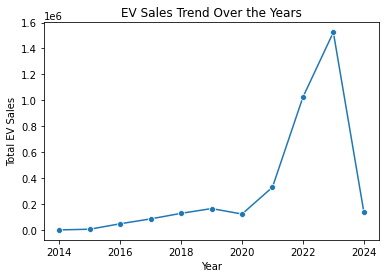

In [18]:
# EV_sales trend over the years
sales_by_year =EV_sales.groupby('Year')['EV_Sales_Quantity'].sum().reset_index()
sns.lineplot(data=sales_by_year, x='Year',y='EV_Sales_Quantity',marker='o')
plt.title('EV Sales Trend Over the Years')
plt.ylabel('Total EV Sales')
plt.xlabel('Year')
plt.show()

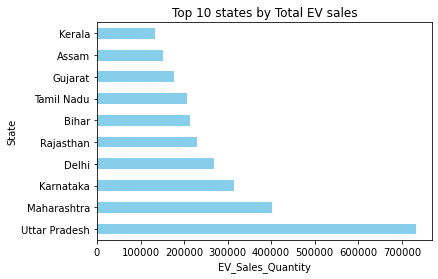

In [19]:
# top ten states by total EV sales
top_states = EV_sales.groupby('State')['EV_Sales_Quantity'].sum().sort_values(ascending=False).head(10)
top_states.plot(kind='barh',color= 'skyblue')
plt.title('Top 10 states by Total EV sales')
plt.xlabel('EV_Sales_Quantity')
plt.gca().invert_yaxis
plt.show()

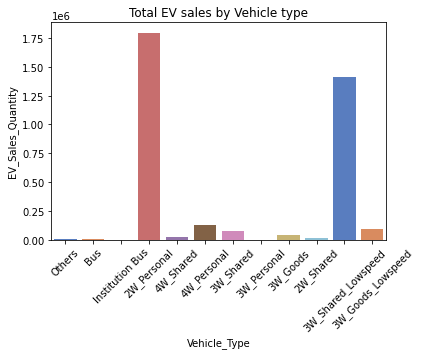

In [20]:
# EV sales by vehicle type
sns.barplot(data=EV_sales, x = 'Vehicle_Type', y ='EV_Sales_Quantity', estimator=sum,ci=None,palette='muted')
plt.title('Total EV sales by Vehicle type')
plt.ylabel('EV_Sales_Quantity')
plt.xticks(rotation=45)
plt.show()

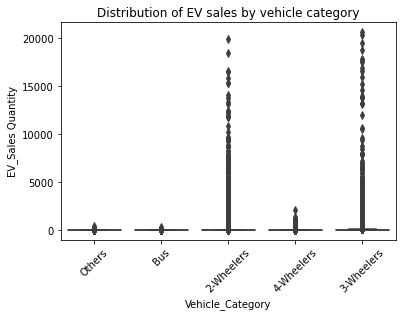

In [21]:
# EV_sales by vehicle category (passenger/commercial)
sns.boxplot(data=EV_sales, x='Vehicle_Category', y = 'EV_Sales_Quantity')
plt.title('Distribution of EV sales by vehicle category')
plt.ylabel('EV_Sales Quantity')
plt.xticks(rotation=45)
plt.show()

In [22]:
# above information we can observed that EV sales have change over time
# which state lead in EV adoption
# which vehicle is most popular

# 5 Feature Engineering

In [23]:
from sklearn.preprocessing import LabelEncoder

# Create more time-based features
EV_sales['Day'] = EV_sales['Date'].dt.day
EV_sales['Weekday'] = EV_sales['Date'].dt.weekday 

# Encode categorical features
label_encoders = {}
categorical_features = ['State', 'Vehicle_Class', 'Vehicle_Category', 'Vehicle_Type']

for col in categorical_features:
    le = LabelEncoder()
    EV_sales[col + '_Code'] = le.fit_transform(EV_sales[col])
    label_encoders[col] = le  

# Select final features and target
features = [
    'Year', 'Month', 'Quarter', 'Day', 'Weekday',
    'State_Code', 'Vehicle_Class_Code',
    'Vehicle_Category_Code', 'Vehicle_Type_Code'
]

X = EV_sales[features]
y = EV_sales['EV_Sales_Quantity']

# Preview final dataset for modeling
print("Features ready for modeling:")
print(X.head())
print("\nTarget variable:")
print(y.head())

Features ready for modeling:
   Year  Month  Quarter  Day  Weekday  State_Code  Vehicle_Class_Code  \
0  2014      1        1    1        2           1                   0   
1  2014      1        1    1        2           1                   1   
2  2014      1        1    1        2           1                   2   
3  2014      1        1    1        2           1                   5   
4  2014      1        1    1        2           1                   9   

   Vehicle_Category_Code  Vehicle_Type_Code  
0                      4                 11  
1                      4                 11  
2                      4                 11  
3                      4                 11  
4                      3                  9  

Target variable:
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: EV_Sales_Quantity, dtype: float64


# 6 Modelling

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# split the dataset
x_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Initialize & train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

# predict on data set
y_pred = model.predict(X_test)

# preview prediction
results_EV_sales = pd.DataFrame({'Actual': y_test.values,'Predicted': y_pred})
print("Sample Predictions:")
print(results_EV_sales.head())

Sample Predictions:
   Actual  Predicted
0     0.0        0.0
1     0.0        0.0
2     0.0        0.0
3     0.0        0.0
4     0.0        0.0


# 7 Model_evalution

In [25]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import numpy as np

In [26]:
# Calculate evalution metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2= r2_score(y_test, y_pred)

In [27]:
# print results
print("Model Evolution Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error(RSME):{rmse:.2f}")
print(f"R^2 score:{r2:.2f}")

Model Evolution Metrics:
Mean Absolute Error (MAE): 12.07
Root Mean Squared Error(RSME):129.43
R^2 score:0.94


# 8 Visualization of model Results

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

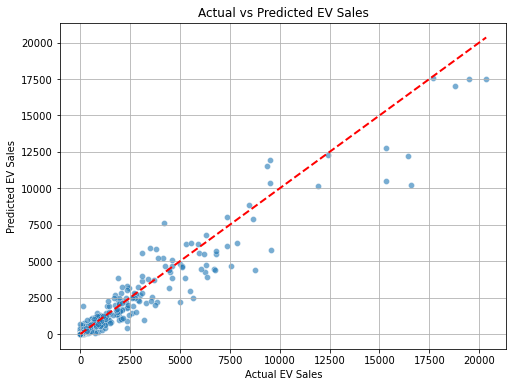

In [29]:
# plot actual vs predicted values
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.6)
plt.plot([y_test.min(), y_test.max()],[y_test.min(),y_test.max()],'r--', lw=2)
plt.xlabel('Actual EV Sales')
plt.ylabel('Predicted EV Sales')
plt.title('Actual vs Predicted EV Sales')
plt.grid(True)
plt.show()

In [30]:
# Feature importance
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
print(feature_importance_df)


Feature Importances:
                 Feature  Importance
5             State_Code    0.499251
0                   Year    0.156952
6     Vehicle_Class_Code    0.146400
8      Vehicle_Type_Code    0.081468
7  Vehicle_Category_Code    0.059683
3                    Day    0.038143
4                Weekday    0.018103
1                  Month    0.000000
2                Quarter    0.000000


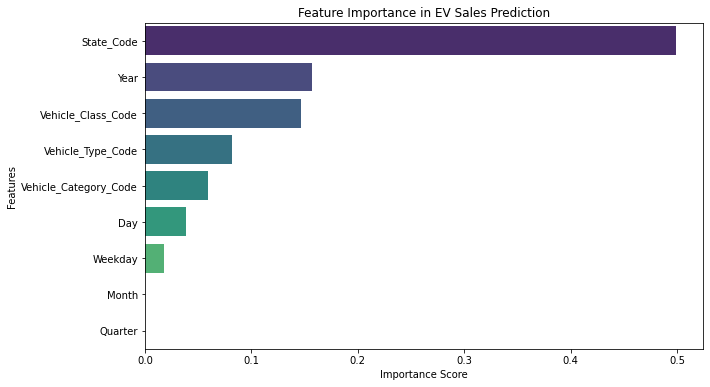

In [31]:
# plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature',palette='viridis')
plt.title('Feature Importance in EV Sales Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Conclusion
The analysis of EV sales in India shows a strong growth trend, with certain states leading in adoption. Two-wheeler and three-wheeler EVs dominate the market. Seasonal variations and policy impacts influence sales. Continuous growth suggests increasing EV acceptance, but infrastructure improvements are crucial for sustained expansion.

